# import

In [8]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:

from ult import *
import multiprocess
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2

# simulation np

In [10]:
# modelname = 'varyreward67noperoid'
# iepoch=22

# # training hyper params
# epoch_size = 33333
# n_epoch = 55
# n_seed = 1
# seed = 0
# no_episodes = 22222  # for eval plot during training
# plot_no_episodes = 555
# vmin, vmax = 10, 10000
# food_reward_list = np.linspace(vmin, vmax, 5)
# attcost = -1.6
# facost = -50
# p1p2 = np.array([.6, .7])
# env_param = [0, None, attcost, .25, facost, 0, 0]
# np.random.seed(seed)


# task = AFR2(spec={'agent': {'lick_cost': env_param[0],
#                             'food_reward': env_param[1],
#                             'attention_cost_coeff': env_param[2],
#                             'attention_cost_temp': env_param[3],
#                             'penalty_cost': env_param[4],
#                             'iti_cost': env_param[5],
#                             'time_in_game_reward': env_param[6]}})
# task.food_reward_list = food_reward_list
# taskbelief = FuncBeliefModel(env=task, rng=1)
# task.obs_certainity_possible = p1p2

# thismodel = f'seed{seed}_{modelname}_{iepoch}'
# model = PPO.load(f'ycstore/{thismodel}')

# # collect trial data
# def eval_wrapper(a):
#     episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
#                               num_steps=100000, deterministic=True)
#     return episode


# with multiprocess.Pool(processes=8) as pool:
#     all_episode_data = pool.map(eval_wrapper, range(no_episodes))

# # process the data. this is slow.
# all_reward_res={} # k: v = foodreward idx: this food reward res
# for r in range(len(food_reward_list)):
#     attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
#     all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len


# for episode in all_episode_data[:]:
#     attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
#     att_time_list.append(
#         np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
 
#     if episode['actions'][-1][0] == 1:
#         lick_time_list.append(len(episode['states']))
#     else:
#         lick_time_list.append(-1)
#     trial_len.append(len(episode['actions']))
# save_pickle_file('figdata/np lick time.pkl', all_episode_data)

In [11]:
all_episode_data = open_pickle_file('figdata/np lick time.pkl')
nplick_time_list=[]
npatt_time_list=[]
for episode in all_episode_data:
    if episode['trial_food_reward_idx']!=2: continue
    npatt_time_list.append(
                np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
    if episode['actions'][-1][0] == 1:
        nplick_time_list.append(len(episode['states']))
    else:
        nplick_time_list.append(-1)

Text(0, 0.5, 'prob')

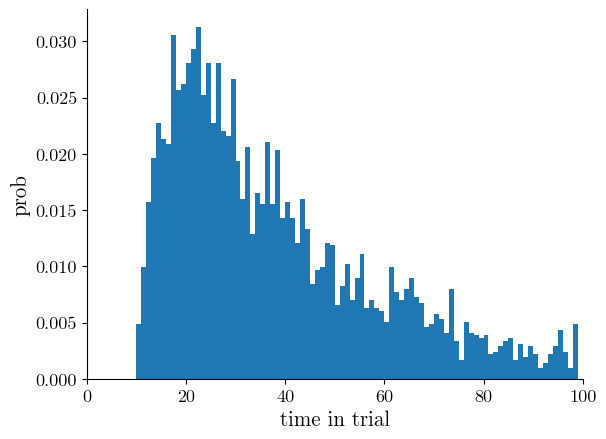

In [12]:
fig,ax=plt.subplots(1,1)
ax.hist(nplick_time_list, bins=np.arange(100), density=True)

plt.xlim(0,100)
plt.xlabel('time in trial')
plt.ylabel('prob')

# simulation p

In [13]:
# modelnamefull='seed_0_varyrewardpv2_epoch_10'
# # modelname = 'varyrewardperoid2'
# # thismodel = f'seed_{seed}_{modelname}_{modeli}'

# # training hyper params
# epoch_size = 33333
# n_epoch = 22
# n_seed = 1
# modeli = 0
# plot_no_episodes = 22222

# no_episodes = 22222
# epochtouse = 8

# attcost = -1.6
# facost = -50
# p1p2 = np.array([.5, .7])
# seed = 0
# np.random.seed(seed)

# vmin, vmax = 10, 10000
# food_reward_list = np.linspace(vmin, vmax, 5)
# env_param = [0, None, attcost, .25, facost, 0, 0]


# task = AFR2(spec={'agent': {'lick_cost': env_param[0],
#                             'food_reward': env_param[1],
#                             'attention_cost_coeff': env_param[2],
#                             'attention_cost_temp': env_param[3],
#                             'penalty_cost': env_param[4],
#                             'iti_cost': env_param[5],
#                             'time_in_game_reward': env_param[6]}})
# task.food_reward_list = food_reward_list
# taskbelief = FuncBeliefModel(env=task, rng=1)
# task.obs_certainity_possible = p1p2
# # model = PPO.load(f'ycstore/{ thismodel}_epoch_{epochtouse}')
# # print(f'ycstore/{thismodel}_epoch_{epochtouse}')
# model=PPO.load(f'ycstore/{modelnamefull}')

# # collect trial data
# def eval_wrapper(a):
#     episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
#                               num_steps=100000, deterministic=True)
#     return episode


# with multiprocess.Pool(processes=8) as pool:
#     all_episode_data = pool.map(eval_wrapper, range(no_episodes))

# # process the data.
# all_reward_res={} # k: v = foodreward idx: this food reward res
# for r in range(len(food_reward_list)):
#     attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
#     all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len


# for episode in all_episode_data[:]:
#     attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
#     att_time_list.append(
#         np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
 
#     if episode['actions'][-1][0] == 1:
#         lick_time_list.append(len(episode['states']))
#     else:
#         lick_time_list.append(-1)
#     trial_len.append(len(episode['actions']))

# save_pickle_file('figdata/p lick time.pkl', all_episode_data)

In [14]:
all_episode_data = open_pickle_file('figdata/p lick time.pkl')
plick_time_list=[]
patt_time_list=[]
for episode in all_episode_data:
    if episode['trial_food_reward_idx']!=2: continue
    patt_time_list.append(
                np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
    
    if episode['actions'][-1][0] == 1:
        plick_time_list.append(len(episode['states']))
    else:
        plick_time_list.append(-1)


Text(0, 0.5, 'prob')

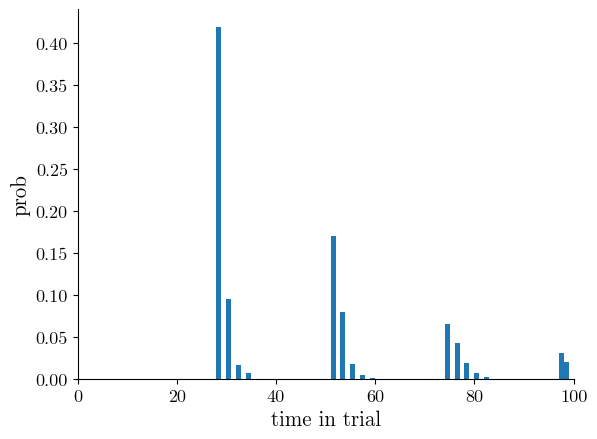

In [15]:
fig,ax=plt.subplots(1,1)
ax.hist(plick_time_list, bins=np.arange(100), density=True)

plt.xlim(0,100)
plt.xlabel('time in trial')
plt.ylabel('prob')

# real data

In [16]:
file_name = './ycstore/analysis_report.pkl'
analysis_report = open_pickle_file(file_name)

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from auditoryforage.AF_env import AuditoryForaging
env = AuditoryForaging()
# one_step_in_seconds = .001
one_step_in_seconds = 3/env.no_signal_nodes #3s being signal duration

metrics_across_blocks = {}
for mouse in analysis_report.keys(): # for across mice
# for mouse in [list(analysis_report.keys())[17]]: # for single mice
    for reward_block in analysis_report[mouse]:
        if reward_block not in metrics_across_blocks.keys():
            metrics_across_blocks[reward_block] = {}
            metrics_across_blocks[reward_block]['hits_per_trial'] = []
            metrics_across_blocks[reward_block]['misses_per_trial'] = []
            metrics_across_blocks[reward_block]['FAs_per_trial'] = []
            metrics_across_blocks[reward_block]['hits_per_signal_duration'] = []
            metrics_across_blocks[reward_block]['FAs_per_noise_duration'] = []
            metrics_across_blocks[reward_block]['hit_reaction_time_list'] = []
            metrics_across_blocks[reward_block]['fa_reaction_time_list'] = []
            metrics_across_blocks[reward_block]['lick_time_list'] = []
            metrics_across_blocks[reward_block]['miss_trial_length_list'] = []
            metrics_across_blocks[reward_block]['hit_lick_time_list'] = []
            metrics_across_blocks[reward_block]['fa_lick_time_list'] = []
        hits_per_trial = analysis_report[mouse][reward_block]['hit_count']/analysis_report[mouse][reward_block]['no_trials']
        missess_per_trial = analysis_report[mouse][reward_block]['miss_count']/analysis_report[mouse][reward_block]['no_trials']
        FAs_per_trial = analysis_report[mouse][reward_block]['false_alarm_count']/analysis_report[mouse][reward_block]['no_trials']
        hits_per_signal_duration = analysis_report[mouse][reward_block]['hit_count']/(analysis_report[mouse][reward_block]['signal_time_before_lick'] * one_step_in_seconds)
        FAs_per_noise_duration = analysis_report[mouse][reward_block]['false_alarm_count']/(analysis_report[mouse][reward_block]['noise_time_before_lick'] * one_step_in_seconds)
        metrics_across_blocks[reward_block]['hits_per_trial'].append(hits_per_trial)
        metrics_across_blocks[reward_block]['misses_per_trial'].append(missess_per_trial)
        metrics_across_blocks[reward_block]['FAs_per_trial'].append(FAs_per_trial)
        metrics_across_blocks[reward_block]['hits_per_signal_duration'].append(hits_per_signal_duration)
        metrics_across_blocks[reward_block]['FAs_per_noise_duration'].append(FAs_per_noise_duration)
        metrics_across_blocks[reward_block]['hit_reaction_time_list'] += analysis_report[mouse][reward_block]['hit_reaction_time_list']
        metrics_across_blocks[reward_block]['fa_reaction_time_list'] += analysis_report[mouse][reward_block]['fa_reaction_time_list']
        metrics_across_blocks[reward_block]['lick_time_list'] += analysis_report[mouse][reward_block]['lick_time_list']
        metrics_across_blocks[reward_block]['miss_trial_length_list'] += analysis_report[mouse][reward_block]['miss_trial_length_list']
        metrics_across_blocks[reward_block]['hit_lick_time_list'] += analysis_report[mouse][reward_block]['hit_lick_time_list']
        metrics_across_blocks[reward_block]['fa_lick_time_list'] += analysis_report[mouse][reward_block]['fa_lick_time_list']


# metrics = ['hits_per_trial', 'misses_per_trial', 'FAs_per_trial', 'hits_per_signal_duration', 'FAs_per_noise_duration','hit_reaction_time_list','fa_reaction_time_list','lick_time_list', 'hit_lick_time_list']
# block_indices_list = ['1.0', '2.0', '3.0', '4.0', '5.0', '6.0']
# for metric in metrics:
#     plt.figure()
#     mean_list = [np.mean(metrics_across_blocks[block_ind][metric]) for block_ind in block_indices_list]
#     sem_list = [np.std(metrics_across_blocks[block_ind][metric])/np.sqrt(len(metrics_across_blocks[block_ind][metric])) for block_ind in block_indices_list]
#     # std_list = [np.std(metrics_across_blocks[block_ind][metric]) for block_ind in block_indices_list]
#     plt.errorbar([float(block_ind) for block_ind in block_indices_list], mean_list, yerr= sem_list, fmt='o', markersize=6, capsize=4)
#     # plt.errorbar([float(block_ind) for block_ind in block_indices_list], mean_list, yerr= std_list, fmt='o', markersize=6, capsize=4)
#     plt.xlabel('reward block index')
#     plt.ylabel(metric)
#     plt.title(metric + f' across blocks (error-bar in s.e.m)')
#     # plt.title(metric + f' across blocks (error-bar in s.t.d)')
#     plt.xticks(np.arange(len(block_indices_list)))  # Set x-axis labels to column indices
#     plt.grid()
#     plt.show()

#     plt.figure()
#     plt.boxplot([metrics_across_blocks[block_ind][metric] for block_ind in block_indices_list], showfliers=False)
#     plt.xticks(np.arange(len(block_indices_list)))  # Set x-axis labels to column indices
#     plt.xlabel('reward block index')
#     plt.ylabel(metric)
#     plt.title(metric + f' across blocks (error-bar in s.e.m)')
#     plt.show()

In [18]:
max_lick_time = 500
def highest_index_of_value(lst, value):
    highest_index = -1  
    for i in range(len(lst)):
        if lst[i] == value:
            highest_index = i  
    return highest_index
block_ind_list = ['1.0', '2.0', '3.0', '4.0', '5.0', '6.0']
rlick_time_list=[]
for block_ind in block_ind_list:
    rlick_time_list += metrics_across_blocks[block_ind]['hit_lick_time_list']


# all 3

webf NOT subset; don't know how to subset; dropped


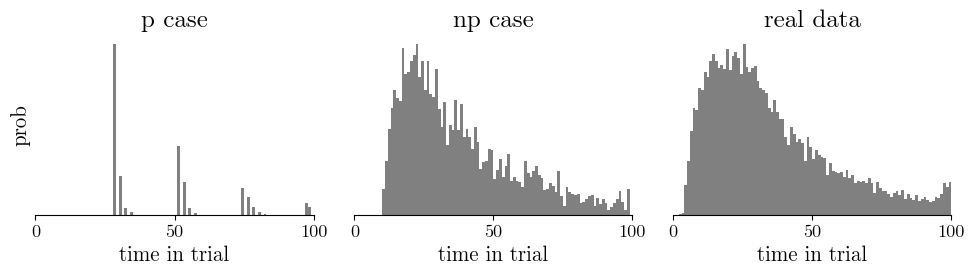

In [19]:
color='grey'
fig, axs=plt.subplots(1,3, figsize=(10,3), sharex=True)
# p
ax=axs[0]
ax.hist(plick_time_list, bins=np.arange(100), density=True, color=color)
ax.set_xlabel('time in trial')
ax.set_ylabel('prob')
ax.set_title('p case')
ax.spines['left'].set_visible(False)
ax.set_yticks([])
ax.set_xticks([0,50,100])
# np
ax=axs[1]
ax.hist(nplick_time_list, bins=np.arange(100), density=True, color=color)
ax.set_xlabel('time in trial')
ax.set_title('np case')
ax.spines['left'].set_visible(False)
ax.set_yticks([])
ax.set_xticks([0,50,100])
# real
ax=axs[2]
block_ind='4.0'
time_list_all = np.sort(np.array(metrics_across_blocks[block_ind]['hit_lick_time_list']))
max_sorted_samples = highest_index_of_value(time_list_all, max_lick_time)
sorted_list = np.sort(np.array(metrics_across_blocks[block_ind]['hit_lick_time_list']))[:max_sorted_samples]
ax.hist(sorted_list, bins=range(min(sorted_list), max(sorted_list) + 1), density=True, color=color)
ax.set_xlim(0,100)
ax.set_xlabel('time in trial')
ax.set_title('real data')
ax.spines['left'].set_visible(False)
ax.set_yticks([])
ax.set_xticks([0,50,100])

plt.tight_layout()
quicksave('3 compare', 'plot lick time', fig=fig)

webf NOT subset; don't know how to subset; dropped


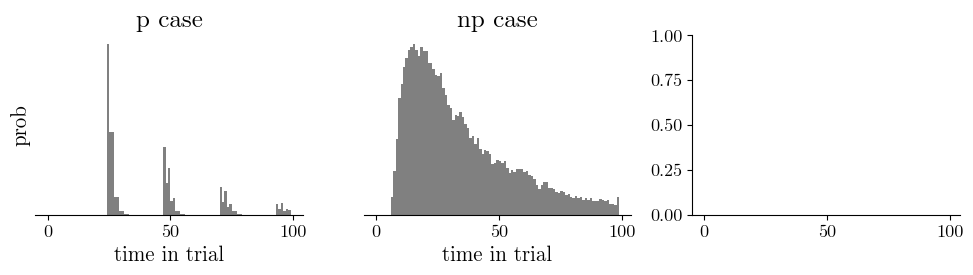

In [24]:
color='grey'
fig, axs=plt.subplots(1,3, figsize=(10,3), sharex=True)
# p
ax=axs[0]
ax.hist(np.concatenate(patt_time_list), bins=np.arange(100), density=True, color=color)
ax.set_xlabel('time in trial')
ax.set_ylabel('prob')
ax.set_title('p case')
ax.spines['left'].set_visible(False)
ax.set_yticks([])
ax.set_xticks([0,50,100])
# np
ax=axs[1]
ax.hist(np.concatenate(npatt_time_list), bins=np.arange(1,100), density=True, color=color)
ax.set_xlabel('time in trial')
ax.set_title('np case')
ax.spines['left'].set_visible(False)
ax.set_yticks([])
ax.set_xticks([0,50,100])


plt.tight_layout()
quicksave('3 compare', 'plot att time', fig=fig)

# Plot lick times

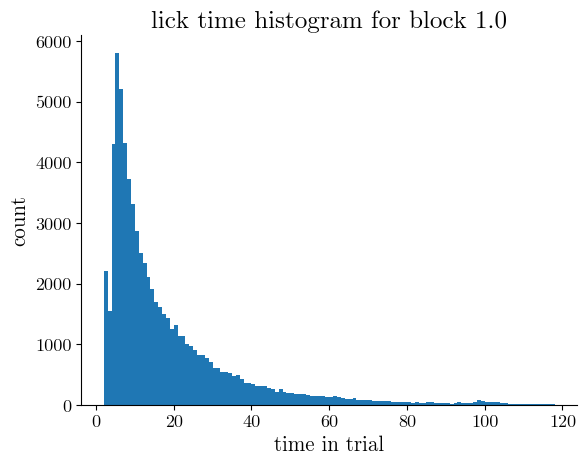

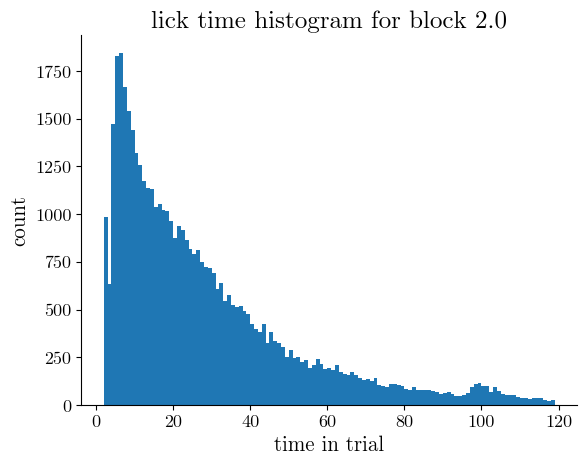

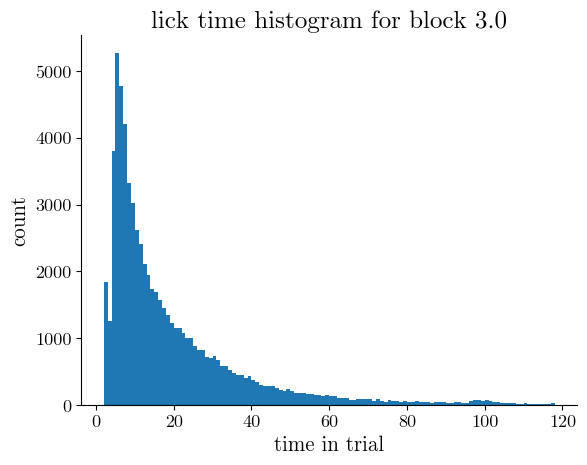

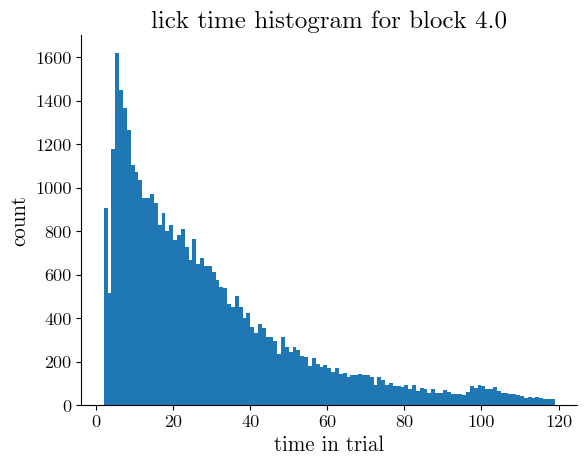

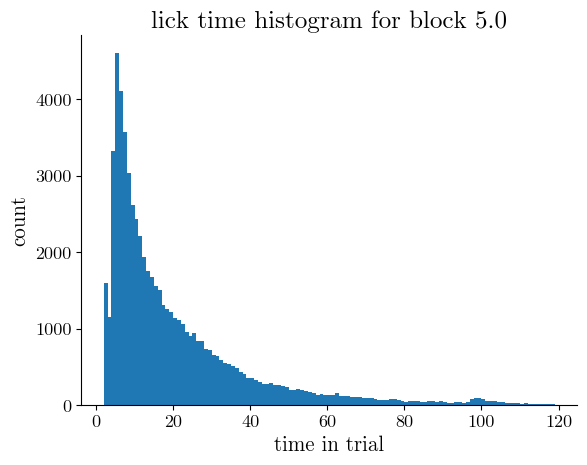

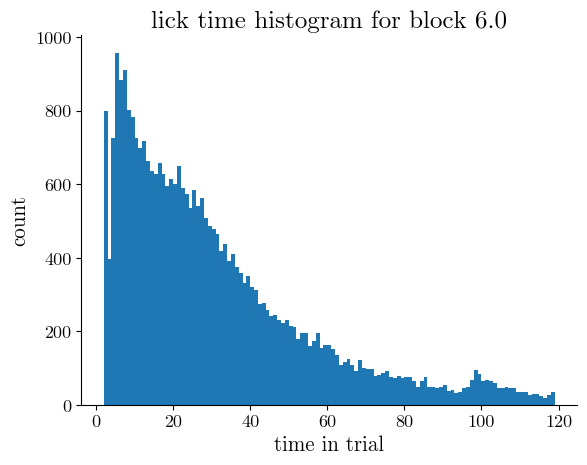

In [ ]:
max_lick_time = 300

def highest_index_of_value(lst, value):
    highest_index = -1  
    for i in range(len(lst)):
        if lst[i] == value:
            highest_index = i  
    return highest_index

block_ind_list = ['1.0', '2.0', '3.0', '4.0', '5.0', '6.0']

for block_ind in block_ind_list:
    time_list_all = np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))
    max_sorted_samples = highest_index_of_value(time_list_all, max_lick_time)
    sorted_list = np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples]
    plt.hist(sorted_list, bins=range(min(sorted_list), max(sorted_list) + 1))
    plt.xlabel('time in trial')
    plt.ylabel('count')
    plt.title(f'lick time histogram for block {block_ind}')
    plt.show()


# hit lick

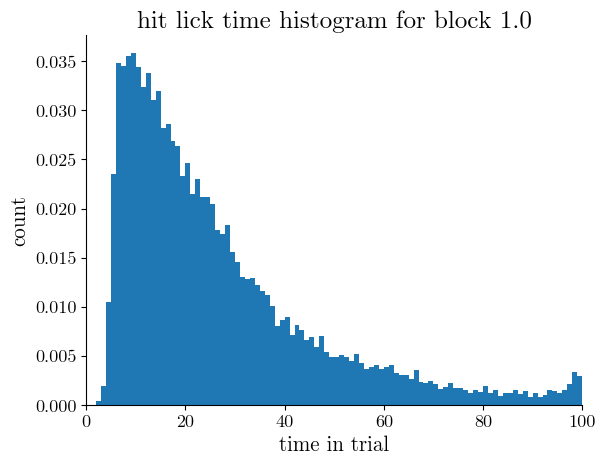

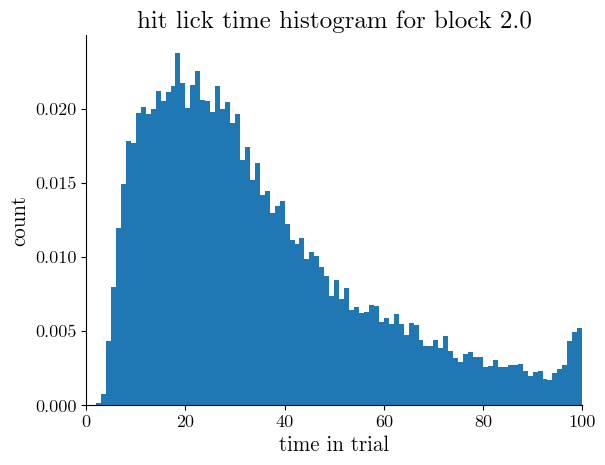

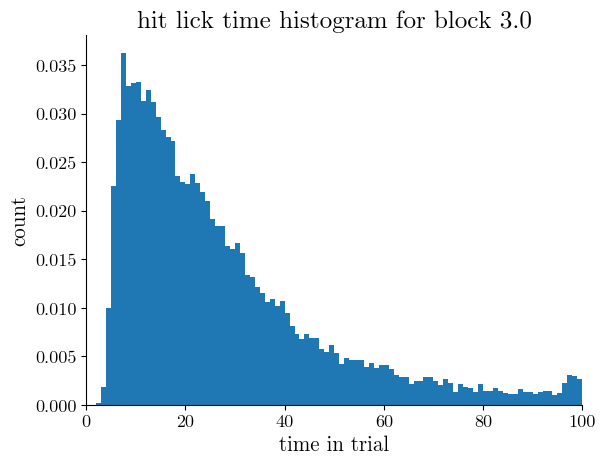

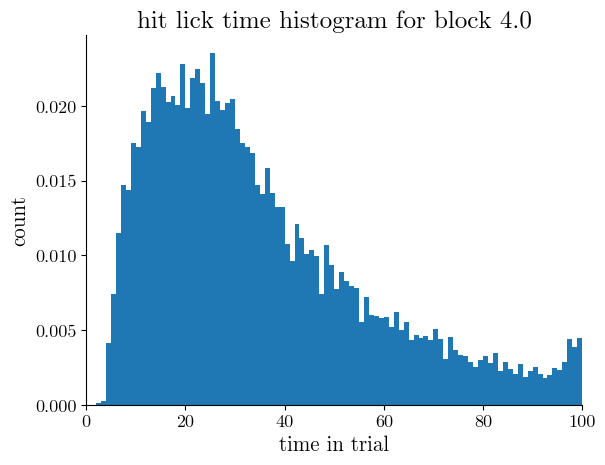

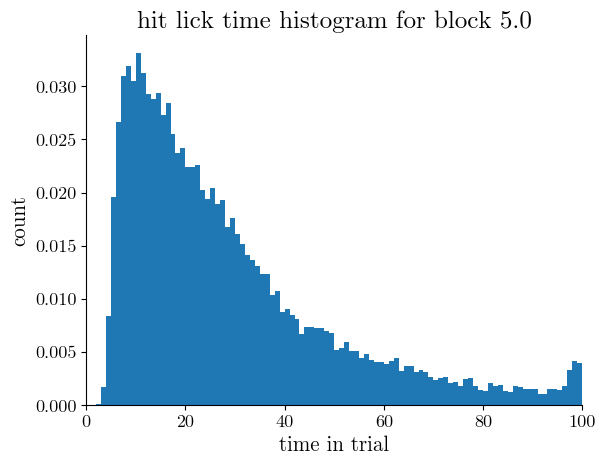

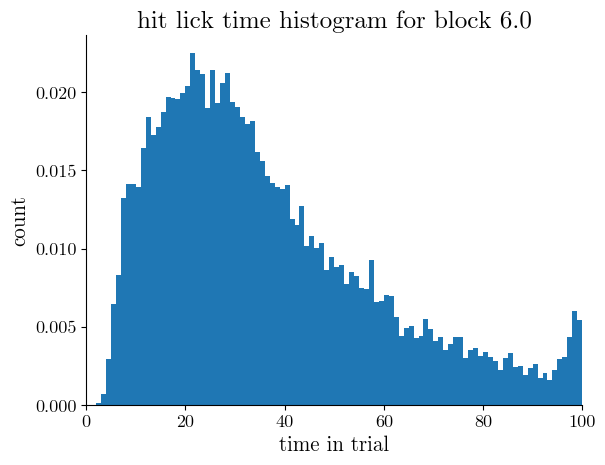

In [ ]:
max_lick_time = 500

def highest_index_of_value(lst, value):
    highest_index = -1  
    for i in range(len(lst)):
        if lst[i] == value:
            highest_index = i  
    return highest_index

block_ind_list = ['1.0', '2.0', '3.0', '4.0', '5.0', '6.0']

for block_ind in block_ind_list:
    time_list_all = np.sort(np.array(metrics_across_blocks[block_ind]['hit_lick_time_list']))
    max_sorted_samples = highest_index_of_value(time_list_all, max_lick_time)
    sorted_list = np.sort(np.array(metrics_across_blocks[block_ind]['hit_lick_time_list']))[:max_sorted_samples]
    plt.hist(sorted_list, bins=range(min(sorted_list), max(sorted_list) + 1), density=True)
    plt.xlim(0,100)
    plt.xlabel('time in trial')
    plt.ylabel('count')
    plt.title(f'hit lick time histogram for block {block_ind}')
    plt.show()


# reaction times

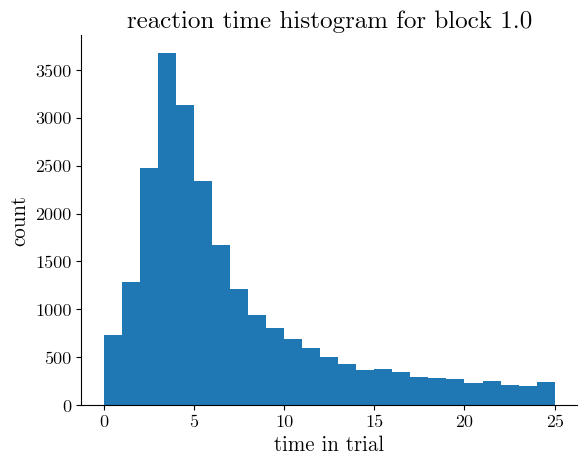

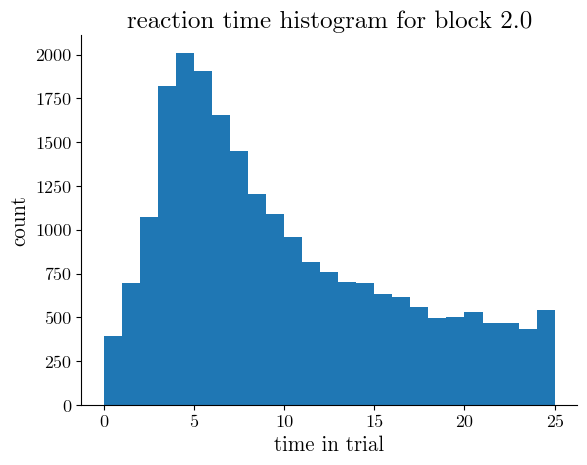

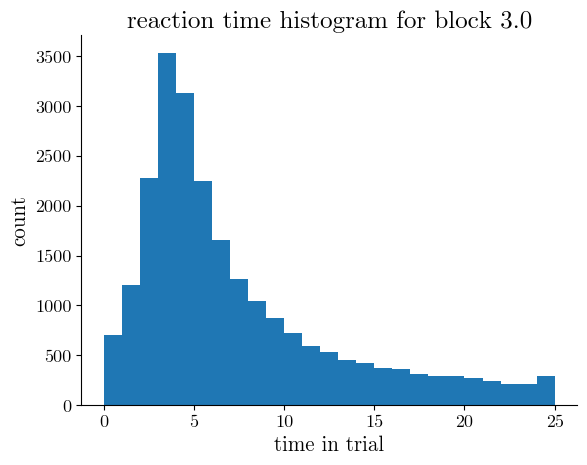

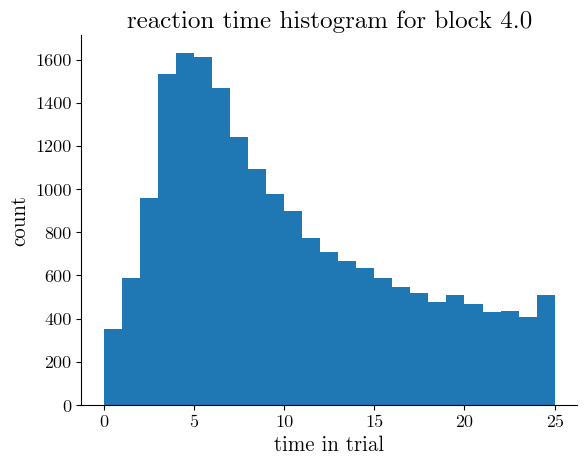

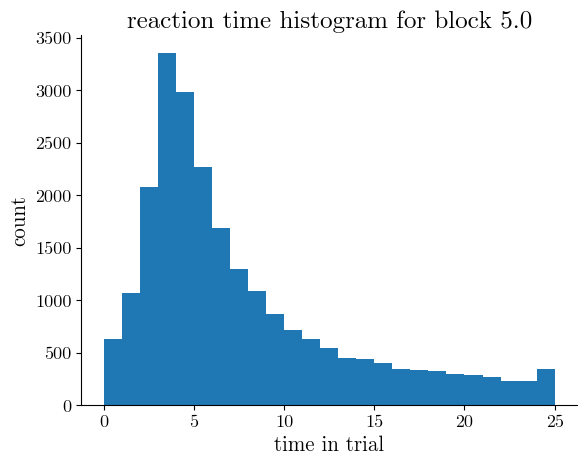

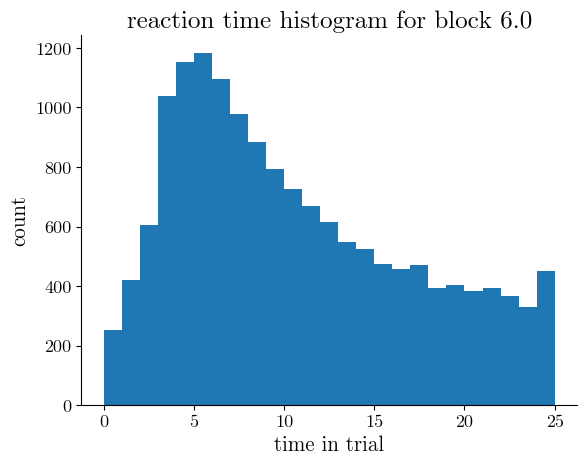

In [ ]:
max_lick_time = 300

def highest_index_of_value(lst, value):
    highest_index = -1  
    for i in range(len(lst)):
        if lst[i] == value:
            highest_index = i  
    return highest_index

block_ind_list = ['1.0', '2.0', '3.0', '4.0', '5.0', '6.0']

for block_ind in block_ind_list:
    time_list_all = np.sort(np.array(metrics_across_blocks[block_ind]['hit_reaction_time_list']))
    max_sorted_samples = highest_index_of_value(time_list_all, max_lick_time)
    sorted_list = np.sort(np.array(metrics_across_blocks[block_ind]['hit_reaction_time_list']))[:max_sorted_samples]
    plt.hist(sorted_list, bins=range(min(sorted_list), max(sorted_list) + 1))
    plt.xlabel('time in trial')
    plt.ylabel('count')
    plt.title(f'reaction time histogram for block {block_ind}')
    plt.show()
